In [7]:
import numpy as np  # Importe NumPy pour manipuler les tableaux et effectuer les calculs numériques.
import matplotlib.pyplot as plt  # Importe matplotlib pour afficher les graphes.

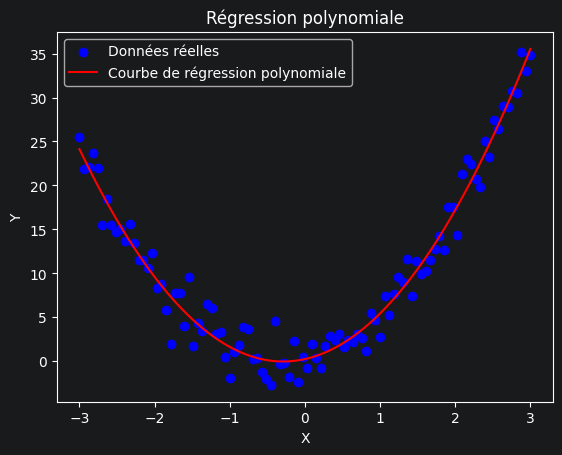

In [8]:
def polynomial_features(X, degree):  # Définit une fonction qui construit les caractéristiques polynomiales.
    n = len(X)  # Récupère le nombre d'exemples dans X.
    X_poly = np.zeros((n, degree + 1))  # Crée une matrice vide avec une colonne par puissance de x.

    for i in range(n):  # Parcourt chaque exemple.
        for d in range(degree + 1):  # Parcourt chaque degré du polynôme.
            X_poly[i][d] = X[i] ** d  # Stocke la valeur de x élevée à la puissance d.

    return X_poly  # Retourne la matrice des variables polynomiales.

def initialize_beta(degree):  # Définit une fonction qui initialise les coefficients du modèle.
    return np.zeros(degree + 1)  # Retourne un vecteur de zéros de taille degree + 1.

def predict(X_poly, beta):  # Définit une fonction qui calcule les prédictions du modèle.
    n = len(X_poly)  # Récupère le nombre d'exemples.
    y_pred = np.zeros(n)  # Initialise un vecteur vide pour stocker les prédictions.

    for i in range(n):  # Parcourt chaque exemple.
        for j in range(len(beta)):  # Parcourt chaque coefficient.
            y_pred[i] += X_poly[i][j] * beta[j]  # Ajoute la contribution de chaque terme polynomial.

    return y_pred  # Retourne les prédictions calculées.

def compute_cost(y_pred, Y):  # Définit une fonction qui calcule le coût moyen quadratique.
    n = len(Y)  # Récupère le nombre d'exemples.
    cost = 0  # Initialise le coût total à 0.

    for i in range(n):  # Parcourt chaque exemple.
        cost += (y_pred[i] - Y[i]) ** 2  # Ajoute l'erreur quadratique de l'exemple courant.

    return cost / n  # Retourne la moyenne des erreurs quadratiques.

def polynomial_regression(X_poly, Y, beta, lr, iterations):  # Définit une fonction qui entraîne le modèle polynomial.
    n = len(Y)  # Récupère le nombre d'exemples.
    costs = []  # Crée une liste vide pour stocker l'évolution du coût.

    for it in range(iterations):  # Lance la boucle d'entraînement.
        y_pred = predict(X_poly, beta)  # Calcule les prédictions actuelles.

        gradients = np.zeros(len(beta))  # Initialise le vecteur des gradients.

        for j in range(len(beta)):  # Parcourt chaque coefficient.
            grad = 0  # Initialise la somme du gradient courant.
            for i in range(n):  # Parcourt chaque exemple.
                grad += (y_pred[i] - Y[i]) * X_poly[i][j]  # Ajoute la contribution de l'exemple au gradient.

            gradients[j] = (2 / n) * grad  # Calcule le gradient moyen pour ce coefficient.

        for j in range(len(beta)):  # Parcourt chaque coefficient.
            beta[j] -= lr * gradients[j]  # Met à jour le coefficient correspondant.

        cost = compute_cost(y_pred, Y)  # Calcule le coût actuel.
        costs.append(cost)  # Ajoute le coût à la liste des coûts.

    return beta, costs  # Retourne les coefficients appris et l'évolution des coûts.

np.random.seed(0)  # Fixe la graine aléatoire pour rendre les résultats reproductibles.
X = np.linspace(-3, 3, 100)  # Génère 100 valeurs de X régulièrement espacées entre -3 et 3.
Y = 1 + 2 * X + 3 * X**2 + np.random.randn(100) * 2  # Génère une relation quadratique bruitée.

degree = 2  # Définit le degré du polynôme.
X_poly = polynomial_features(X, degree)  # Transforme X en variables polynomiales.
beta = initialize_beta(degree)  # Initialise les coefficients du modèle.
lr = 0.01  # Définit le taux d'apprentissage.
iterations = 1000  # Définit le nombre d'itérations d'entraînement.

beta, costs = polynomial_regression(X_poly, Y, beta, lr, iterations)  # Entraîne le modèle polynomial.

X_plot = np.linspace(X.min(), X.max(), 200)  # Génère des points plus fins pour tracer une courbe lisse.
X_plot_poly = polynomial_features(X_plot, degree)  # Transforme les points de tracé en variables polynomiales.
Y_plot = predict(X_plot_poly, beta)  # Calcule les prédictions sur les points de tracé.

plt.scatter(X, Y, color='blue', label='Données réelles')  # Affiche les données d'origine sous forme de points bleus.
plt.plot(X_plot, Y_plot, color='red', label='Courbe de régression polynomiale')  # Trace la courbe de régression polynomiale en rouge.
plt.xlabel('X')  # Définit le label de l'axe des abscisses.
plt.ylabel('Y')  # Définit le label de l'axe des ordonnées.
plt.title('Régression polynomiale')  # Définit le titre du graphique.
plt.legend()  # Affiche la légende.
plt.show()  # Affiche le graph des données et de la courbe.